In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Import custom modules
from utils.spike_detection import SpikeDetector
from utils.neural_behavioral_alignment import NeuralBehavioralAligner
from utils.ridge_decoder import RidgeVelocityDecoder
from utils.h5_data_loader import H5DataLoader

print("🧠 Ridge Regression Velocity Decoding Pipeline")
print("=" * 50)
print("✅ All modules imported successfully")


🧠 Ridge Regression Velocity Decoding Pipeline
✅ All modules imported successfully


In [2]:
# Configuration
CONFIG = {
    # Data parameters
    'h5_file_path': r"D:\Data\ScienceCorp\trials_aligned.h5",  # Hardcoded path
    'trial_numbers': list(range(1, 21)),  # First 20 trials
    
    # Spike detection parameters
    'sampling_rate': 30000.0,  # Hz
    'threshold_factor': 5.0,
    'spike_window': (-10, 32),  # samples
    
    # Good channels from neural_feature_exploration
    'good_channels': [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84],
    
    # Alignment parameters
    'bin_size': 0.05,  # 50ms bins
    'interpolation_method': 'linear',
    
    # Decoder parameters
    'alpha': 1.0,  # Ridge regression regularization
    'normalize_features': True,
    'normalize_targets': False,
    'test_size': 0.2,
    
    # Cross-validation
    'cv_folds': 5,
    'alpha_search_range': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
    
    # Visualization
    'max_channels_plot': 5,
    'figsize': (12, 8)
}

print("📋 Configuration:")
for key, value in CONFIG.items():
    if key != 'good_channels':  # Skip long list
        print(f"  • {key}: {value}")
print(f"  • good_channels: {len(CONFIG['good_channels'])} channels")


📋 Configuration:
  • h5_file_path: D:\Data\ScienceCorp\trials_aligned.h5
  • trial_numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
  • sampling_rate: 30000.0
  • threshold_factor: 5.0
  • spike_window: (-10, 32)
  • bin_size: 0.05
  • interpolation_method: linear
  • alpha: 1.0
  • normalize_features: True
  • normalize_targets: False
  • test_size: 0.2
  • cv_folds: 5
  • alpha_search_range: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
  • max_channels_plot: 5
  • figsize: (12, 8)
  • good_channels: 21 channels


In [3]:
# Use hardcoded H5 file path from CONFIG
h5_file_path = CONFIG['h5_file_path']
print(f"📂 Using hardcoded H5 file: {h5_file_path}")

# Verify file path is set
if not h5_file_path:
    raise ValueError("H5 file path not configured in CONFIG")

# Initialize spike detector
spike_detector = SpikeDetector(
    sampling_rate=CONFIG['sampling_rate'],
    threshold_factor=CONFIG['threshold_factor'],
    spike_window=CONFIG['spike_window'],
    good_channels=CONFIG['good_channels']
)

# Initialize aligner
aligner = NeuralBehavioralAligner(
    bin_size=CONFIG['bin_size'],
    interpolation_method=CONFIG['interpolation_method']
)

print(f"\n✅ Pipeline components initialized:")
print(f"  • Spike detector: {len(CONFIG['good_channels'])} channels")
print(f"  • Aligner: {CONFIG['bin_size']*1000:.0f}ms bins")
print(f"  • Ready to process {len(CONFIG['trial_numbers'])} trials")


📂 Using hardcoded H5 file: D:\Data\ScienceCorp\trials_aligned.h5
🔧 Filters initialized (300-3000 Hz bandpass, 500 Hz highpass)
🔍 SpikeDetector initialized:
  • Sampling rate: 30.0 kHz
  • Threshold factor: 5.0
  • Spike window: (-10, 32)
  • Good channels: 21
🔗 NeuralBehavioralAligner initialized:
  • Bin size: 50ms
  • Interpolation: linear

✅ Pipeline components initialized:
  • Spike detector: 21 channels
  • Aligner: 50ms bins
  • Ready to process 20 trials


In [4]:
# Process multiple trials to create training dataset
print(f"🔄 Processing {len(CONFIG['trial_numbers'])} trials for training...")
print("This may take several minutes - extracting spikes and aligning data...")

# This will take some time - be patient!
neural_features_all, behavioral_targets_all = aligner.process_multiple_trials(
    h5_file_path, CONFIG['trial_numbers'], spike_detector)

print(f"\n✅ Dataset created:")
print(f"  • Neural features: {neural_features_all.shape}")
print(f"  • Behavioral targets: {behavioral_targets_all.shape}")
print(f"  • Total time bins: {neural_features_all.shape[0]}")
print(f"  • Total duration: {neural_features_all.shape[0] * CONFIG['bin_size']:.1f} seconds")

# Dataset statistics
print(f"\n📊 Dataset Statistics:")
print(f"  • Neural activity range: {np.min(neural_features_all):.2f} to {np.max(neural_features_all):.2f} Hz")
print(f"  • Velocity X range: {np.min(behavioral_targets_all[:, 0]):.3f} to {np.max(behavioral_targets_all[:, 0]):.3f}")
print(f"  • Velocity Y range: {np.min(behavioral_targets_all[:, 1]):.3f} to {np.max(behavioral_targets_all[:, 1]):.3f}")
print(f"  • Non-zero velocity samples: {np.sum(np.sqrt(behavioral_targets_all[:, 0]**2 + behavioral_targets_all[:, 1]**2) > 0.01)}")

# Initialize and train Ridge decoder
print(f"\n🧠 Training Ridge regression decoder...")
decoder = RidgeVelocityDecoder(
    alpha=CONFIG['alpha'],
    normalize_features=CONFIG['normalize_features'],
    normalize_targets=CONFIG['normalize_targets']
)

training_results = decoder.train(
    neural_features_all, 
    behavioral_targets_all,
    test_size=CONFIG['test_size'],
    random_state=42
)

print(f"\n✅ Training complete!")
print(f"  • Training samples: {training_results['train_samples']}")
print(f"  • Test samples: {training_results['test_samples']}")
print(f"  • R² velocity_x: {training_results['r2_x']:.3f}")
print(f"  • R² velocity_y: {training_results['r2_y']:.3f}")
print(f"  • Overall correlation: {training_results['overall_correlation']:.3f}")

# Hyperparameter search
print(f"\n🔍 Searching for optimal hyperparameters...")
hp_results = decoder.hyperparameter_search(
    neural_features_all,
    behavioral_targets_all,
    alpha_range=CONFIG['alpha_search_range'],
    cv_folds=CONFIG['cv_folds']
)

best_alpha = hp_results['best_alpha']
best_r2 = hp_results['best_result']['overall_mean_r2']
print(f"  • Best alpha: {best_alpha}")
print(f"  • Best R²: {best_r2:.3f}")

# Retrain with best hyperparameters if needed
if best_alpha != CONFIG['alpha']:
    print(f"\n🔄 Retraining with optimal alpha = {best_alpha}...")
    
    best_decoder = RidgeVelocityDecoder(
        alpha=best_alpha,
        normalize_features=CONFIG['normalize_features'],
        normalize_targets=CONFIG['normalize_targets']
    )
    
    best_training_results = best_decoder.train(
        neural_features_all, 
        behavioral_targets_all,
        test_size=CONFIG['test_size'],
        random_state=42
    )
    
    print(f"  • Improved R² velocity_x: {best_training_results['r2_x']:.3f}")
    print(f"  • Improved R² velocity_y: {best_training_results['r2_y']:.3f}")
    print(f"  • Improved overall correlation: {best_training_results['overall_correlation']:.3f}")
    
    # Use best decoder for evaluation
    decoder = best_decoder
    training_results = best_training_results
else:
    print(f"✅ Current alpha is already optimal")


🔄 Processing 20 trials for training...
This may take several minutes - extracting spikes and aligning data...
🔄 Processing 20 trials...
📂 Loading trial 1 data...
✅ Trial 1 loaded:
  • Neural data: (96, 1090964)
  • Velocity data: 1407 samples
  • Duration: 36.17s
🔍 Extracting spike features from trial 1
🔍 Detecting spikes across 21 channels...
🔧 Preprocessing neural data: (96, 1090964)
✅ Signal preprocessing complete
✅ Spike detection complete: 10509 spikes across 21 channels
🔥 Computing firing rates (bin size: 50ms)
✅ Firing rates computed: 724 bins x 21 channels
✅ Features extracted for trial 1
  ✅ Trial 1: 724 time bins
📂 Loading trial 2 data...
✅ Trial 2 loaded:
  • Neural data: (96, 87168)
  • Velocity data: 106 samples
  • Duration: 2.71s
🔍 Extracting spike features from trial 2
🔍 Detecting spikes across 21 channels...
🔧 Preprocessing neural data: (96, 87168)
✅ Signal preprocessing complete
✅ Spike detection complete: 827 spikes across 21 channels
🔥 Computing firing rates (bin si

🔄 Performing cross-validation...
🔄 Performing 5-fold cross-validation...
✅ Cross-validation complete:
  • R² velocity_x: 1.000 ± 0.000
  • R² velocity_y: 1.000 ± 0.000

📊 Cross-validation results:
  • Mean R² velocity_x: 1.000 ± 0.000
  • Mean R² velocity_y: 1.000 ± 0.000
  • Overall mean R²: 1.000

📋 Performance Report:
Ridge Velocity Decoder Performance Report

Model Configuration:
  • Alpha (regularization): 0.001
  • Feature normalization: True
  • Target normalization: False
  • Training samples: 1444
  • Test samples: 361
  • Neural channels: 21

Performance Metrics:
  • R² Velocity X: 1.000
  • R² Velocity Y: 1.000
  • MSE Velocity X: 0.000
  • MSE Velocity Y: 0.000
  • Correlation Velocity X: nan (p=nan)
  • Correlation Velocity Y: nan (p=nan)
  • Overall Correlation: nan (p=nan)

Direction Decoding:
  • Direction Error (mean): 0.000 rad
  • Direction Error (std): 0.000 rad

📊 Creating visualizations...


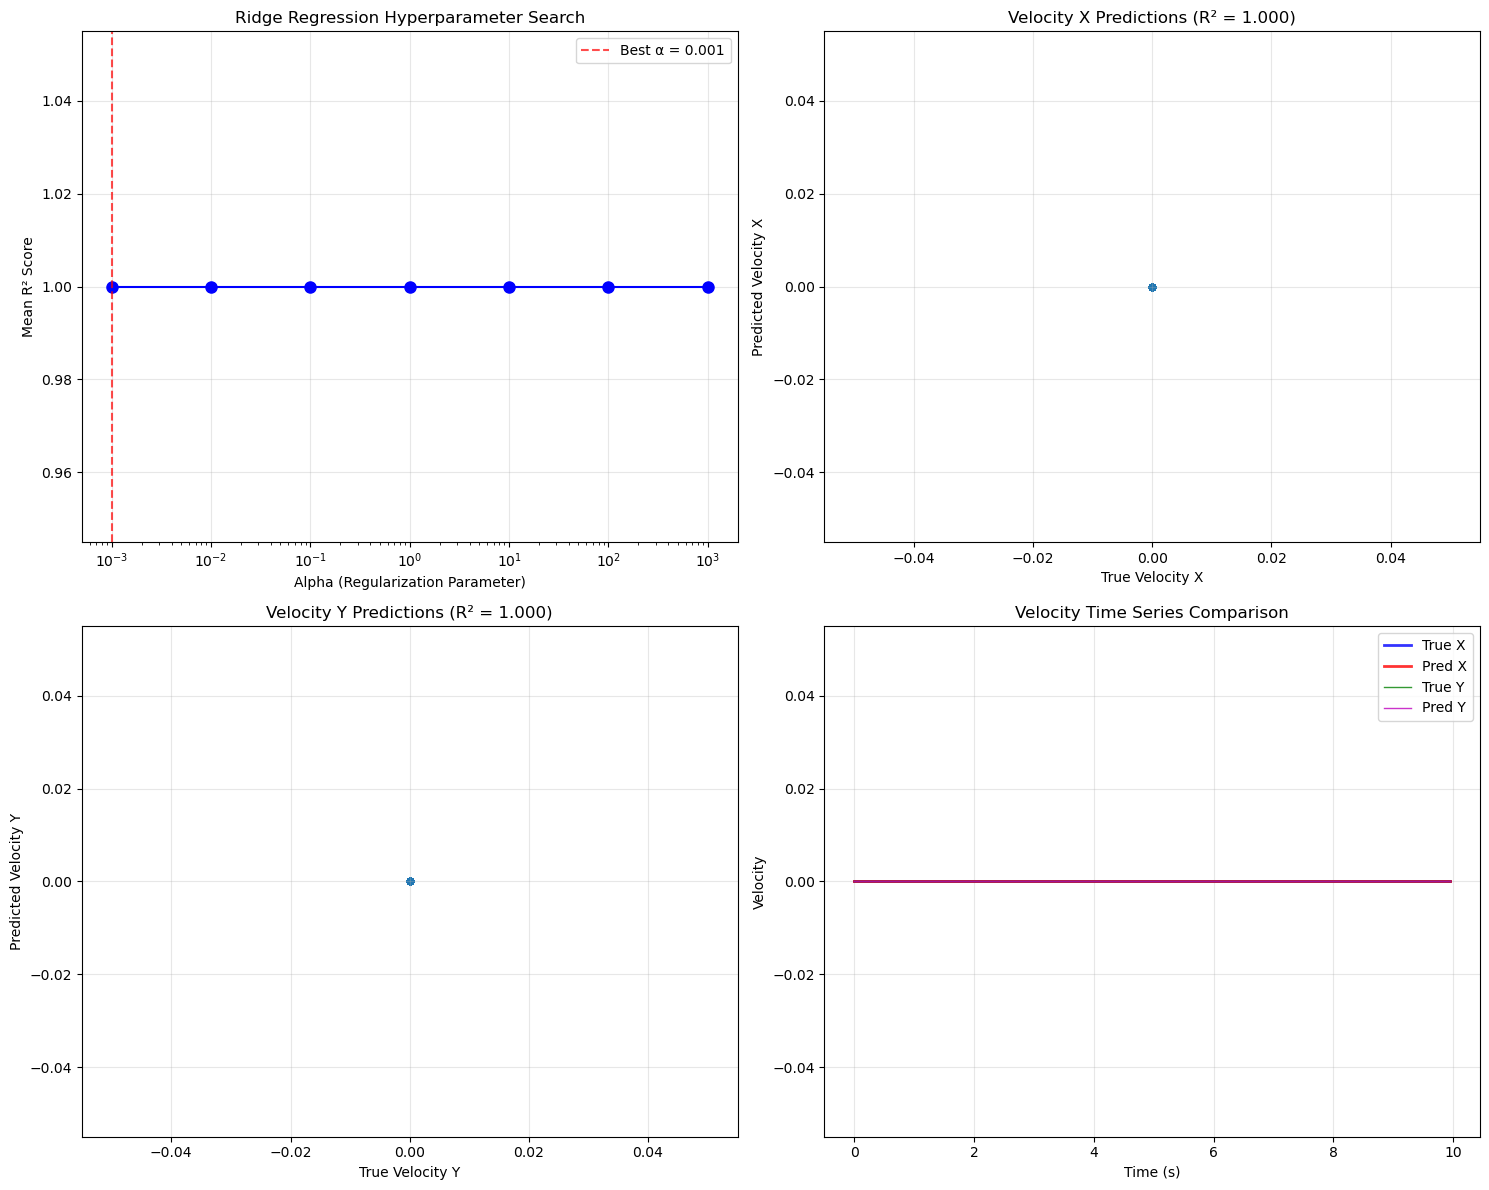


📊 Feature importance (regression coefficients)...


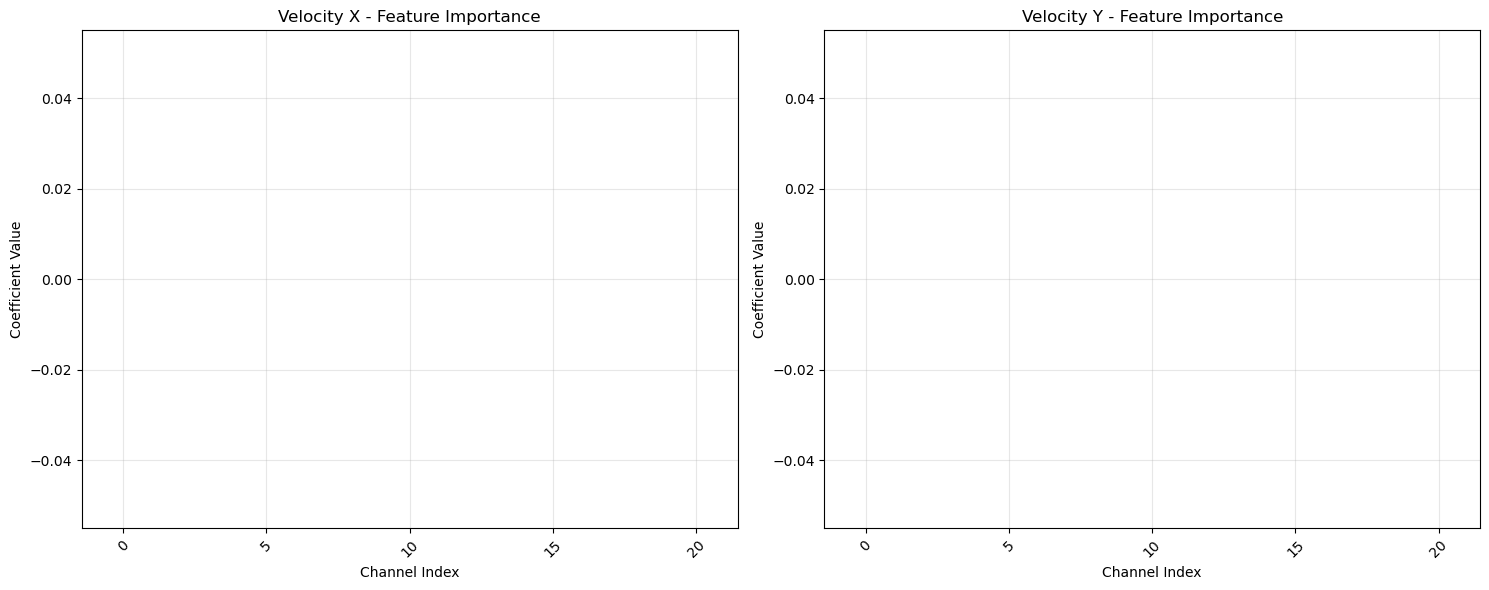


📊 Direction decoding analysis...
📊 Direction Analysis Results:
  • Mean direction error: 0.000 rad (0.0°)
  • Std direction error: 0.000 rad (0.0°)
  • Magnitude correlation: nan

🎯 Ridge Regression Velocity Decoding - Summary:
  • Best R² velocity_x: 1.000
  • Best R² velocity_y: 1.000
  • Overall correlation: nan
  • Cross-validation R²: 1.000
  • Direction accuracy: 0.0° mean error

✅ Ridge regression velocity decoding analysis complete!


In [5]:
# Cross-validation evaluation
print("🔄 Performing cross-validation...")
cv_results = decoder.cross_validate(
    neural_features_all,
    behavioral_targets_all,
    cv_folds=CONFIG['cv_folds']
)

print(f"\n📊 Cross-validation results:")
print(f"  • Mean R² velocity_x: {cv_results['mean_r2_x']:.3f} ± {cv_results['std_r2_x']:.3f}")
print(f"  • Mean R² velocity_y: {cv_results['mean_r2_y']:.3f} ± {cv_results['std_r2_y']:.3f}")
print(f"  • Overall mean R²: {cv_results['overall_mean_r2']:.3f}")

# Generate performance report
print("\n📋 Performance Report:")
print(decoder.generate_report())

# Visualizations
print("\n📊 Creating visualizations...")

# 1. Plot hyperparameter search results
alphas = [r['alpha'] for r in hp_results['results']]
r2_scores = [r['overall_mean_r2'] for r in hp_results['results']]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Hyperparameter search
axes[0, 0].semilogx(alphas, r2_scores, 'bo-', markersize=8)
axes[0, 0].axvline(best_alpha, color='r', linestyle='--', alpha=0.7, label=f'Best α = {best_alpha}')
axes[0, 0].set_xlabel('Alpha (Regularization Parameter)')
axes[0, 0].set_ylabel('Mean R² Score')
axes[0, 0].set_title('Ridge Regression Hyperparameter Search')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Get test predictions for visualization
X_test, y_test, y_pred = training_results['test_data']

# Velocity X predictions
axes[0, 1].scatter(y_test[:, 0], y_pred[:, 0], alpha=0.5, s=20)
axes[0, 1].plot([y_test[:, 0].min(), y_test[:, 0].max()], 
               [y_test[:, 0].min(), y_test[:, 0].max()], 'r--', lw=2)
axes[0, 1].set_xlabel('True Velocity X')
axes[0, 1].set_ylabel('Predicted Velocity X')
axes[0, 1].set_title(f'Velocity X Predictions (R² = {training_results["r2_x"]:.3f})')
axes[0, 1].grid(True, alpha=0.3)

# Velocity Y predictions
axes[1, 0].scatter(y_test[:, 1], y_pred[:, 1], alpha=0.5, s=20)
axes[1, 0].plot([y_test[:, 1].min(), y_test[:, 1].max()], 
               [y_test[:, 1].min(), y_test[:, 1].max()], 'r--', lw=2)
axes[1, 0].set_xlabel('True Velocity Y')
axes[1, 0].set_ylabel('Predicted Velocity Y')
axes[1, 0].set_title(f'Velocity Y Predictions (R² = {training_results["r2_y"]:.3f})')
axes[1, 0].grid(True, alpha=0.3)

# Time series comparison (first 200 samples)
n_samples = min(200, len(y_test))
time_axis = np.arange(n_samples) * CONFIG['bin_size']

axes[1, 1].plot(time_axis, y_test[:n_samples, 0], 'b-', label='True X', alpha=0.8, linewidth=2)
axes[1, 1].plot(time_axis, y_pred[:n_samples, 0], 'r-', label='Pred X', alpha=0.8, linewidth=2)
axes[1, 1].plot(time_axis, y_test[:n_samples, 1], 'g-', label='True Y', alpha=0.8, linewidth=1)
axes[1, 1].plot(time_axis, y_pred[:n_samples, 1], 'm-', label='Pred Y', alpha=0.8, linewidth=1)
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Velocity')
axes[1, 1].set_title('Velocity Time Series Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance visualization
print("\n📊 Feature importance (regression coefficients)...")
coefs_x = decoder.model_x.coef_
coefs_y = decoder.model_y.coef_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Velocity X coefficients
channel_labels = [f'Ch{ch}' for ch in CONFIG['good_channels']]
axes[0].bar(range(len(coefs_x)), coefs_x, alpha=0.7)
axes[0].set_xlabel('Channel Index')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Velocity X - Feature Importance')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Velocity Y coefficients
axes[1].bar(range(len(coefs_y)), coefs_y, alpha=0.7)
axes[1].set_xlabel('Channel Index')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Velocity Y - Feature Importance')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Direction analysis
print("\n📊 Direction decoding analysis...")
true_directions = np.arctan2(y_test[:, 1], y_test[:, 0])
pred_directions = np.arctan2(y_pred[:, 1], y_pred[:, 0])
direction_errors = np.abs(np.angle(np.exp(1j * (true_directions - pred_directions))))

true_magnitudes = np.sqrt(y_test[:, 0]**2 + y_test[:, 1]**2)
pred_magnitudes = np.sqrt(y_pred[:, 0]**2 + y_pred[:, 1]**2)

print(f"📊 Direction Analysis Results:")
print(f"  • Mean direction error: {np.mean(direction_errors):.3f} rad ({np.mean(direction_errors)*180/np.pi:.1f}°)")
print(f"  • Std direction error: {np.std(direction_errors):.3f} rad ({np.std(direction_errors)*180/np.pi:.1f}°)")
print(f"  • Magnitude correlation: {np.corrcoef(true_magnitudes, pred_magnitudes)[0,1]:.3f}")

print(f"\n🎯 Ridge Regression Velocity Decoding - Summary:")
print(f"  • Best R² velocity_x: {training_results['r2_x']:.3f}")
print(f"  • Best R² velocity_y: {training_results['r2_y']:.3f}")
print(f"  • Overall correlation: {training_results['overall_correlation']:.3f}")
print(f"  • Cross-validation R²: {cv_results['overall_mean_r2']:.3f}")
print(f"  • Direction accuracy: {np.mean(direction_errors)*180/np.pi:.1f}° mean error")
print(f"\n✅ Ridge regression velocity decoding analysis complete!")
